#### Quick survivalpredict walkthrough demo

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

%matplotlib inline

from survivalpredict.estimators import CoxProportionalHazard, ParametricDiscreteTimePH, KaplanMeierSurvivalEstimator, KNeighborsSurvival, CoxNNetPH
from survivalpredict.strata_preprocessing import StrataBuilderDiscretizer, StrataBuilderEncoder
from survivalpredict.metrics import brier_scores_administrative, integrated_brier_score_administrative
from survivalpredict.validation import sur_cross_val_score
from survivalpredict.model_selection import Sur_GridSearchCV
from survivalpredict.datasets import load_iranian_telecom_churn

from sklearn.preprocessing import StandardScaler

In [2]:
#loading some stock data
iranian_telecom_churn = load_iranian_telecom_churn()

#X is our design matrix/features
X_raw = iranian_telecom_churn['X']
ss = StandardScaler()
X = ss.fit_transform(X_raw)

times = iranian_telecom_churn['times'].astype(np.int64)
events = iranian_telecom_churn['events'].astype(np.bool_)
column_names = iranian_telecom_churn["column_names"]

#### A quick note on time
The times array should be the last known interval of survival, regardless of whether the individual experienced the event (i.e., death, churn, conversion) or is still 'alive' or in an unknown state. The times array is assumed to possess the type of integer for 'survivalpredict'. It is up to the user to encode the time array. It is recommended, if possible, to maximize the times array to a few thousand for significant datasets. Presence of large times can trigger alot of computation for various estimators. It is common to map time to the age of an entity, like the length of time of an individual as a cutomer.

In [3]:
times

array([38, 39, 37, ..., 18, 11, 11], shape=(3150,))

In [4]:
times.max()

np.int64(47)

#### Events
The ‘events’ array should indicate if an individual has experienced the event of interest. Meaning that if said individual has churned, failed, convereted or whatever else, at the time interval; the row is coded as ‘True’, and ‘False’ if otherwise. It is assumed to be boolean, or castable to boolean type.

In [5]:
events

array([False, False, False, ..., False, False,  True], shape=(3150,))

The estimators of survivalpredict are very much like scikit-learn's. But on fit,instead of 'estimator.fit(X,y)' we call 'estimator.fit(X,times,events)'

In [6]:
cox = CoxProportionalHazard()

cox.fit(X,times,events)

,alpha,0.0
,l1_ratio,0.5
,max_iter,100
,ties,'breslow'
,tol,1e-09


In [7]:
#getting coef for each feature
dict(zip(map(str,column_names), map(float,cox.coef_)))

{'call_failure': 0.4656662503827164,
 'complains': 1.8829341579938057,
 'charge_amount': -0.40937529187142296,
 'seconds_of_use': 0.29837689062637685,
 'frequency_of_use': -2.173154255802621,
 'frequency_of_sms': -3.0279468588329532,
 'distinct_called_numbers': -0.29707817534951325,
 'age_group': -0.3465183450012194,
 'tariff_plan': 0.134561966604143,
 'status': -0.06233669084308485,
 'age': 0.268829547578736,
 'customer_value': 1.87481967428526}

When we call '.predict' on an estimator, we will get the predicted survival curve for each individual. Each row in the predicted array corresponds to the row we ran predict on. Each column represents a point in time, starting with the ‘1’ interval of the ‘times’ array we trained on. By default, the left-most column goes till the max time seen in the training data, but we can set the max time by the  max_time key word argument on predict.

In [8]:
max_time=times.max()
preds = cox.predict(X,max_time=max_time)

In [9]:
times_of_survival_curve = np.arange(1,max_time +1)

pd.DataFrame(preds, columns=times_of_survival_curve)

,1,2,3,4,5,6,7,8,9,10,...,38,39,40,41,42,43,44,45,46,47
0,1.0,1.0,0.999993,0.999989,0.999984,0.999976,0.999959,0.999949,0.999931,0.999921,...,0.997695,0.997124,0.996583,0.995977,0.995272,9.938953e-01,8.511736e-01,7.702958e-01,7.702958e-01,7.702958e-01
1,1.0,1.0,0.999971,0.999956,0.999933,0.999903,0.999833,0.999793,0.999719,0.999677,...,0.990594,0.988274,0.986081,0.983626,0.980778,9.752335e-01,5.168825e-01,3.434077e-01,3.434077e-01,3.434077e-01
2,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999,0.999999,0.999999,...,0.999972,0.999965,0.999958,0.999951,0.999942,9.999254e-01,9.980399e-01,9.968273e-01,9.968273e-01,9.968273e-01
3,1.0,1.0,0.999987,0.999981,0.999971,0.999958,0.999927,0.999910,0.999878,0.999860,...,0.995903,0.994889,0.993929,0.992853,0.991603,9.891640e-01,7.507322e-01,6.285442e-01,6.285442e-01,6.285442e-01
4,1.0,1.0,0.999993,0.999990,0.999984,0.999977,0.999961,0.999951,0.999934,0.999924,...,0.997768,0.997215,0.996692,0.996104,0.995422,9.940885e-01,8.555385e-01,7.767036e-01,7.767036e-01,7.767036e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,1.0,1.0,0.999999,0.999999,0.999999,0.999998,0.999997,0.999996,0.999995,0.999994,...,0.999827,0.999784,0.999743,0.999698,0.999644,9.995406e-01,9.879815e-01,9.806074e-01,9.806074e-01,9.806074e-01
3146,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.999991,0.999989,0.999987,0.999985,0.999982,9.999773e-01,9.994037e-01,9.990344e-01,9.990344e-01,9.990344e-01
3147,1.0,1.0,0.999997,0.999995,0.999992,0.999989,0.999981,0.999976,0.999967,0.999963,...,0.998905,0.998633,0.998376,0.998088,0.997752,9.970966e-01,9.263402e-01,8.834493e-01,8.834493e-01,8.834493e-01
3148,1.0,1.0,0.999999,0.999999,0.999998,0.999997,0.999996,0.999994,0.999992,0.999991,...,0.999747,0.999684,0.999625,0.999558,0.999480,9.993286e-01,9.824821e-01,9.717824e-01,9.717824e-01,9.717824e-01


We can also visualize some of our predicted survival curves.

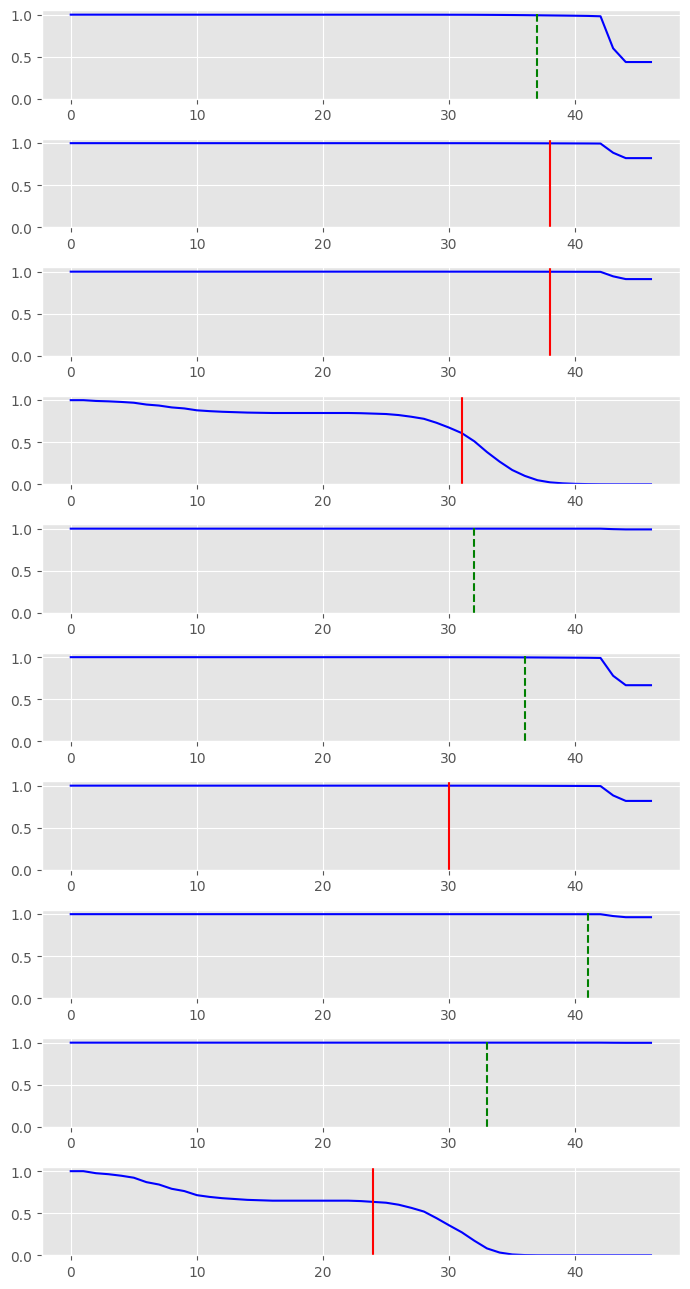

In [10]:
n_failed_to_show = 5
n_censored_to_show = 5
n_rand_rows_to_show = n_failed_to_show + n_censored_to_show

random_rows_failed = np.random.choice( np.arange(0,preds.shape[0] )[events.astype(np.bool)]   ,size=n_failed_to_show, replace=False)
random_rows_censored = np.random.choice( np.arange(0,preds.shape[0])[~events.astype(np.bool)] ,size=n_censored_to_show, replace=False)
n_rand_rows_to_show = np.concat((random_rows_failed,random_rows_censored))
np.random.shuffle(n_rand_rows_to_show)


fig, axs = plt.subplots(len(n_rand_rows_to_show))
fig.set_figheight(13)
fig.set_figwidth(7)

for a,i in enumerate(n_rand_rows_to_show):
    axs[a].set_ylim(0.0,1.05)
    axs[a].plot(preds[i],color='b')

    if events[i]:
        axs[a].axvline(x = times[i], color = 'r', label = 'event')
    else:
        axs[a].axvline(x = times[i], color = 'g', label = 'event',linestyle='--')

fig.tight_layout()


Within survival analysis literature, it is not uncommon to use some form of the ‘brier score’ to assess the performance of a model’s predicted survival curves. Lower the values the better.

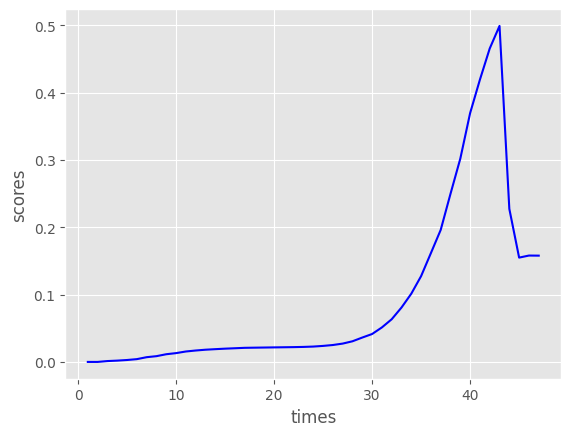

In [11]:
scores = brier_scores_administrative(preds,times,events)

plt.xlabel('times')
plt.ylabel('scores') 
plt.plot(times_of_survival_curve,scores,color='b')

The integral of the ‘brier scores’ are used as a singular metric.

In [12]:
integrated_brier_score_administrative(preds,times,events)

np.float64(4.225046295847599)

Within statistical learning methodologies, cross-validation is considered an important cornerstone of prediction evaluation. 'survivalpredict' comes with some tooling to evaluate models with cross-validation.

In [13]:
sur_cross_val_score(CoxProportionalHazard(),
                    X,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                    scoring='integrated_brier_score_administrative').mean()

np.float64(0.08481151161944717)

It is a good idea to compare the performance of your models against the Kaplan Meier univariate survival curve. This would be analogous to sklearn’s dummy estimators.

In [14]:
sur_cross_val_score(KaplanMeierSurvivalEstimator(),
                    X,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                    scoring='integrated_brier_score_administrative').mean()

#the lower the better, it seems that the cox model has a lower integrated brier score than the dummy KaplanMeier model.

np.float64(0.10246271782806733)

If you wish to train a model with strata, fitting becomes 'estimator.fit(X,times,events, strata=strata)’.
and predict becomes 'estimator.predict(X, strata=strata)'. The strata array should be an array with integer values. We also have tools for building strata. It is common practice to remove the column/columns used to build the strata.

In [15]:
#getting the position of the age column of the numpy array
position_of_age_col = int(
    np.argwhere(column_names == "age")[0][0]
)
age = X[:, position_of_age_col]



sbd = StrataBuilderDiscretizer(n_bins=3,strategy='uniform')

strata = sbd.fit_transform(age)
X_without_strata = X[:,~np.isin(range(X.shape[1]), position_of_age_col)]

In [16]:
cox_with_strata = CoxProportionalHazard()

cox_with_strata.fit(X_without_strata,times,events,strata=strata)
_ = cox_with_strata.predict(X_without_strata,strata=strata)


We can see a significant improvement in the cross-validation score after adding the strata to our cox model.

In [17]:
sur_cross_val_score(CoxProportionalHazard(),
                    X_without_strata,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                    strata = strata,
                    scoring='integrated_brier_score_administrative'
                   ).mean()

np.float64(0.044762868990537455)

we could have also make our strata from categorical data.

In [18]:
StrataBuilderEncoder().fit_transform(['a','b','b','c'])

array([0, 1, 1, 2])

#### On Base Hazards

The Cox Proportional Hazards model famously avoids estimating the base hazard. Rather, it uses  Breslow’s non-parametric estimator for relative risk. This can lead to stepwise and sporadic base hazard.

In [19]:
#notice the 0's at diffrent points in time
cox._breslow_base_hazard

array([0.00000000e+00, 0.00000000e+00, 4.22362623e-06, 2.11185727e-06,
       3.23049888e-06, 4.36391890e-06, 1.00938202e-05, 5.73938244e-06,
       1.06450882e-05, 5.99679788e-06, 1.13141900e-05, 5.06075672e-06,
       3.81145763e-06, 2.55188701e-06, 2.57106780e-06, 1.28562813e-06,
       1.28623916e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.29690188e-06,
       2.62215977e-06, 2.62261275e-06, 6.70512152e-06, 1.10353441e-05,
       1.39089749e-05, 2.81904663e-05, 3.69440115e-05, 4.53947482e-05,
       7.88527319e-05, 1.29201916e-04, 1.57957811e-04, 2.07469988e-04,
       2.38680946e-04, 3.23737833e-04, 3.37293381e-04, 3.19367161e-04,
       3.58466069e-04, 4.16940175e-04, 8.15280093e-04, 9.12927357e-02,
       5.87992106e-02, 0.00000000e+00, 0.00000000e+00])

(0.0, 0.0001)

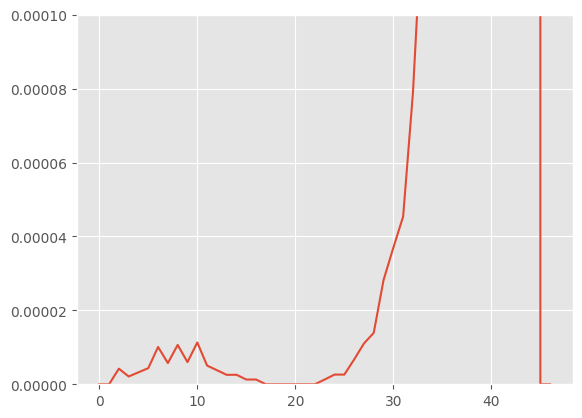

In [20]:
plt.plot(cox._breslow_base_hazard,)
#zooming in
plt.ylim(0.,.0001)

In [21]:
cox._breslow_base_hazard

array([0.00000000e+00, 0.00000000e+00, 4.22362623e-06, 2.11185727e-06,
       3.23049888e-06, 4.36391890e-06, 1.00938202e-05, 5.73938244e-06,
       1.06450882e-05, 5.99679788e-06, 1.13141900e-05, 5.06075672e-06,
       3.81145763e-06, 2.55188701e-06, 2.57106780e-06, 1.28562813e-06,
       1.28623916e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.29690188e-06,
       2.62215977e-06, 2.62261275e-06, 6.70512152e-06, 1.10353441e-05,
       1.39089749e-05, 2.81904663e-05, 3.69440115e-05, 4.53947482e-05,
       7.88527319e-05, 1.29201916e-04, 1.57957811e-04, 2.07469988e-04,
       2.38680946e-04, 3.23737833e-04, 3.37293381e-04, 3.19367161e-04,
       3.58466069e-04, 4.16940175e-04, 8.15280093e-04, 9.12927357e-02,
       5.87992106e-02, 0.00000000e+00, 0.00000000e+00])

The ParametricDiscreteTimePH estimator allows us to estimate a proportional hazards model with its coefficients and base-hazard concurrently. ParametricDiscreteTimePH has multiple options for the base hazard distributions. The typical hazard distributions are implemented: namely, "weibull","log_normal","log_logistic","gamma" and "gompertz". The flexible “chen” and “additive chen weibull” are present as well. It should be noted that ParametricDiscreteTimePH  is far more expensive to train than Cox, and cannot be blindly used in most situations. Be careful to set 'pytensor_mode' to 'NUMBA' or'FAST_COMPILE' when using multiprocessing, as JAX is not multiprocessing safe. ParametricDiscreteTimePH is using pymc under the hood, and we have access to both the coefficient and base hazards priors via the ‘coef_prior_normal_sigma’ and ‘base_harard_prior_exponential_lam’ parameters, respectively.

In [22]:
pph = ParametricDiscreteTimePH(distribution='chen',pytensor_mode='JAX')
pph

,distribution,'chen'
,alpha,0.0
,l1_ratio,0.5
,pytensor_mode,'JAX'
,strata_uses_pytensor_scan,False
,coef_prior_normal_sigma,1.5
,base_harard_prior_exponential_lam,5.0
,scipy_minimize_method,'L-BFGS-B'


In [23]:
pph.fit(X,times,events)
integrated_brier_score_administrative(pph.predict(X,max_time=max_time),times,events)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


np.float64(2.368922849108123)

We can easily interpret that ParametricDiscreteTimePH's base hazard.

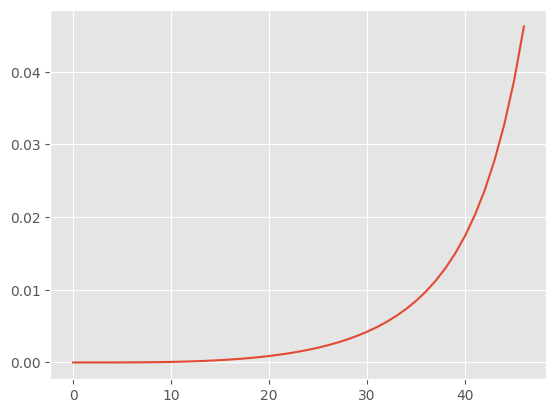

In [24]:
plt.plot(pph.get_base_hazard())

In [25]:
pph.coef_

array([ 0.36387475,  0.45423797, -0.11316963,  0.42097301, -2.23271764,
       -1.92065642, -0.41782933,  0.21545313,  0.24167876, -0.43505684,
       -0.55561674,  0.67399218])

In [26]:
np.unique_counts(strata)

UniqueCountsResult(values=array([0, 1, 2]), counts=array([ 123, 2462,  565]))

We can also run the ParametricDiscreteTimePH with strata. Each strata will have its own distribution. In cases where different distribution structures exist per strata, it is recommended to run one of the Chen family distributions, as they roughly approximate other univariate hazard distributions.

In [27]:
pph_with_strata = ParametricDiscreteTimePH(distribution='additive_chen_weibull', pytensor_mode='JAX',coef_prior_normal_sigma=5,alpha=10)

pph_with_strata.fit(X_without_strata,times,events,strata=strata)
pph_with_strata_predict = pph_with_strata.predict(X_without_strata,strata=strata)


In [28]:
integrated_brier_score_administrative(pph_with_strata_predict,times,events)

np.float64(4.87355748776348)

In [29]:
pph_with_strata.coef_

array([ 0.35455539,  0.44061257,  0.00493953, -0.01356059, -2.06696696,
       -2.84337392, -0.14974594, -0.11260497,  0.15761777, -0.27331311,
        1.48878247])

In [30]:
pph_with_strata.base_hazard_prams_

array([[3.11430514e-21, 6.85923042e-19, 3.38282589e-04, 2.52480691e-37],
       [2.10782513e-13, 4.53224781e-08, 8.86688357e-11, 1.13029609e-04],
       [2.36534325e-02, 1.45358858e+01, 1.34539067e-04, 2.49485575e-29]])

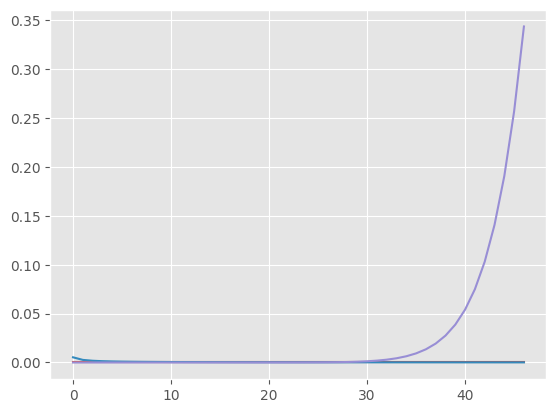

In [31]:
#base hazard per strata
#plt.ylim(0.,.0001)
plt.plot(pph_with_strata.get_base_hazard().T)

In [32]:
#this will take a while, feel free to skip this
sur_cross_val_score(ParametricDiscreteTimePH(distribution='chen',pytensor_mode='JAX',coef_prior_normal_sigma=5,alpha=10),
                    X_without_strata,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                    strata = strata,
                    scoring='integrated_brier_score_administrative'
                   ).mean()


np.float64(0.051178872769317166)

In [33]:
pph_with_strata = ParametricDiscreteTimePH(distribution='additive_chen_weibull', pytensor_mode='JAX')

pph_with_strata.fit(X_without_strata,times,events,strata=strata)
pph_with_strata_predict = pph_with_strata.predict(X_without_strata,strata=strata)


#### Non-interpretive models and GridSearchCV

We also have access to models that lack interpretive power, like K-Nearest Neighbors and Neural networks.

In [34]:
sur_cross_val_score(KNeighborsSurvival(),
                    X,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                   ).mean()


np.float64(0.035210042166676295)

In [35]:
nn = CoxNNetPH(hidden_layers=[50],max_iter=150)
nn.fit(X,times,events) 
#quick note, we can also stratify the CoxNNetPH model

,hidden_layers,[50]
,alpha,0.0
,l1_ratio,0.5
,init_dis,'uniform'
,track_loss,True
,max_iter,150
,gradient_updater,'adam'
,learning_rate,0.01
,beta1,0.9
,beta2,0.999
,epsilon,1e-07


In [36]:
integrated_brier_score_administrative(nn.predict(X,max_time=max_time),times,events)

np.float64(1.3122340073860455)

In [37]:
sur_cross_val_score(CoxNNetPH(hidden_layers=[50],max_iter=150),
                    X,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                   ).mean()


np.float64(0.029857721154598504)


Finally, it should be noted that we have access to hyperparameter tuneing tools, much like scikit-learn.

In [38]:
grid = {'n_neighbors':[5,10,50,100]}
knn_gscv = Sur_GridSearchCV(estimator=KNeighborsSurvival(),cv=10,param_grid=grid)


In [39]:
#warning, this will take a while
knn_gscv.fit(X,times,events)


,estimator,KNeighborsSurvival()
,param_grid,"{'n_neighbors': [5, 10, ...]}"
,brier_score_max_time,None
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [40]:
gscv_results = pd.DataFrame(knn_gscv.cv_results_)

In [41]:
gscv_results.sort_values('rank_test_score').head(5)

,params,param_n_neighbors,rank_test_score,mean_fit_time,std_fit_time,mean_test_scores,std_test_scores,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score
0,{'n_neighbors': 5},5,1,0.005134,0.000271,1.586677,0.383159,2.392802,1.629911,1.200597,1.703998,1.904668,1.306964,1.741952,1.307275,1.692615,0.985988
1,{'n_neighbors': 10},10,2,0.005221,0.000244,1.654872,0.379803,2.265041,2.003174,1.114686,1.754821,1.994142,1.795310,1.407095,1.546741,1.675230,0.992480
2,{'n_neighbors': 50},50,3,0.005267,0.000424,2.069845,0.484736,2.308040,2.066184,1.935281,2.568745,2.515525,2.754340,2.284523,1.576388,1.438373,1.251052
3,{'n_neighbors': 100},100,4,0.005088,0.000560,2.299540,0.527179,2.295040,1.984076,2.146886,2.724492,2.934456,3.182299,2.660396,1.832815,1.703744,1.531201


In [42]:
knn = KNeighborsSurvival(**gscv_results[gscv_results['rank_test_score'] == 1]['params'].values[0])

sur_cross_val_score(knn,
                    X,
                    times,
                    events,
                    brier_score_max_time=max_time,
                    cv=10,
                   ).mean()


np.float64(0.03375908603139525)